# **Wellbeing in the UK**

---

### **Report Overview**

This notebook explores local authority wellbeing using four Office for National Statistics (ONS) indicators: anxiety, happiness, life satisfaction, and whether people feel the things they do in life are worthwhile. The aim is to produce a clear, decision-maker-focused analysis that allows local authorities to be compared with national averages, benchmarked against one another, and assessed over time.

In line with the project brief, the notebook combines data cleaning, analysis and visualisation, with commentary throughout to explain both the technical steps taken and the meaning of the results. The steps are generally structured (where possible) to begin with the question being answered, followed by annotated code, and finally a summary of what the result/visualisation means.

### **What This Report Covers**

**Stage 1: Data Extraction and Exploration**
1. Load and inspect the data
2. Clean and prepare the data
3. Combine the datasets into a single analysis table
4. Review missing values and data quality

**Stage 2: Data Analysis and Insight Visualisation**

5. Calculate national averages
6. Analyse trends over time
7. Benchmark local authorities
8. Compare selected authorities and indicators
9. Interactive comparison over time

**Stage 3: Findings and Discussion**

10. Key findings for decision makers
11. Limitations
12. Questions for further local enquiry
13. AI Usage Log



---



# Stage 1: Data Extraction and Exploration

**1. Load and inspect the data**

I began by loading the four ONS datasets. Before loading them, I inspected the raw dataset and observed the CSV files include metadata above the main table, so used skiprows=7, so that pandas begins reading from the correct header row. I used a loop for efficiency, and finally printed my inspection in an accessible way.

In [ ]:
import pandas as pd

# Load the four ONS wellbeing datasets
anxiety = pd.read_csv("anxiety-table-data.csv", skiprows=7)
happiness = pd.read_csv("happiness-table-data.csv", skiprows=7)
satisfaction = pd.read_csv("satisfaction-table-data.csv", skiprows=7)
worthwhile = pd.read_csv("worthwhile-table-data.csv", skiprows=7)

# Store them in a dictionary so they are easier to inspect together
datasets = {
    "Anxiety": anxiety,
    "Happiness": happiness,
    "Satisfaction": satisfaction,
    "Worthwhile": worthwhile
}

# Inspect the structure of each dataset
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")
    print("Shape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData types:")
    print(df.dtypes)

    print("\nFirst 5 rows:")
    display(df.head())

    print("\nNull values by column:")
    print(df.isnull().sum())


Anxiety
Shape: (374, 14)

Columns:
['Area code', 'Area name', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']

Data types:
Area code     object
Area name     object
2011-12      float64
2012-13      float64
2013-14      float64
2014-15      float64
2015-16      float64
2016-17      float64
2017-18      float64
2018-19      float64
2019-20      float64
2020-21      float64
2021-22      float64
2022-23      float64
dtype: object

First 5 rows:


,Area code,Area name,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23
0,E06000001,Hartlepool,2.96,2.75,2.79,2.63,2.88,2.80,2.79,2.74,3.26,3.39,3.30,3.48
1,E06000002,Middlesbrough,3.59,3.03,3.14,2.99,2.83,2.87,2.99,2.75,2.77,3.11,3.02,3.07
2,E06000003,Redcar and Cleveland,3.11,3.04,2.91,2.66,2.86,2.69,2.73,2.61,2.66,3.15,2.73,3.25
3,E06000004,Stockton-on-Tees,3.03,2.96,2.86,2.84,2.81,2.61,2.79,2.39,3.14,3.26,3.18,3.23
4,E06000005,Darlington,2.87,2.84,2.79,2.92,2.83,2.77,2.79,2.98,3.09,3.63,3.29,3.38



Null values by column:
Area code     0
Area name     0
2011-12      15
2012-13       4
2013-14       4
2014-15       4
2015-16       4
2016-17       4
2017-18       5
2018-19       5
2019-20       3
2020-21       4
2021-22       5
2022-23      11
dtype: int64

Happiness
Shape: (374, 14)

Columns:
['Area code', 'Area name', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']

Data types:
Area code     object
Area name     object
2011-12      float64
2012-13      float64
2013-14      float64
2014-15      float64
2015-16      float64
2016-17      float64
2017-18      float64
2018-19      float64
2019-20      float64
2020-21      float64
2021-22      float64
2022-23      float64
dtype: object

First 5 rows:


,Area code,Area name,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23
0,E06000001,Hartlepool,7.27,7.15,7.40,7.50,7.26,7.44,7.47,7.39,7.30,7.21,7.54,7.57
1,E06000002,Middlesbrough,7.14,7.27,7.24,7.32,7.50,7.53,7.39,7.43,7.21,7.26,7.41,7.05
2,E06000003,Redcar and Cleveland,7.26,7.25,7.43,7.47,7.46,7.40,7.60,7.59,7.49,7.49,7.46,7.49
3,E06000004,Stockton-on-Tees,7.24,7.25,7.46,7.56,7.46,7.53,7.56,7.60,7.37,7.25,7.23,7.29
4,E06000005,Darlington,7.36,7.24,7.40,7.48,7.56,7.49,7.54,7.58,7.59,7.12,7.35,7.17



Null values by column:
Area code     0
Area name     0
2011-12      15
2012-13       4
2013-14       4
2014-15       4
2015-16       4
2016-17       4
2017-18       5
2018-19       5
2019-20       3
2020-21       4
2021-22       5
2022-23      11
dtype: int64

Satisfaction
Shape: (374, 14)

Columns:
['Area code', 'Area name', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']

Data types:
Area code     object
Area name     object
2011-12      float64
2012-13      float64
2013-14      float64
2014-15      float64
2015-16      float64
2016-17      float64
2017-18      float64
2018-19      float64
2019-20      float64
2020-21      float64
2021-22      float64
2022-23      float64
dtype: object

First 5 rows:


,Area code,Area name,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23
0,E06000001,Hartlepool,7.48,7.32,7.48,7.66,7.56,7.56,7.49,7.56,7.60,7.33,7.42,7.29
1,E06000002,Middlesbrough,7.41,7.39,7.41,7.53,7.72,7.64,7.62,7.61,7.45,7.21,7.50,7.35
2,E06000003,Redcar and Cleveland,7.45,7.53,7.57,7.60,7.63,7.63,7.72,7.71,7.59,7.44,7.50,7.25
3,E06000004,Stockton-on-Tees,7.54,7.53,7.60,7.70,7.61,7.72,7.79,7.68,7.66,7.40,7.30,7.33
4,E06000005,Darlington,7.50,7.46,7.59,7.68,7.62,7.61,7.74,7.73,7.71,7.25,7.37,7.32



Null values by column:
Area code     0
Area name     0
2011-12      15
2012-13       4
2013-14       4
2014-15       4
2015-16       4
2016-17       4
2017-18       5
2018-19       5
2019-20       3
2020-21       4
2021-22       5
2022-23      11
dtype: int64

Worthwhile
Shape: (374, 14)

Columns:
['Area code', 'Area name', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']

Data types:
Area code     object
Area name     object
2011-12      float64
2012-13      float64
2013-14      float64
2014-15      float64
2015-16      float64
2016-17      float64
2017-18      float64
2018-19      float64
2019-20      float64
2020-21      float64
2021-22      float64
2022-23      float64
dtype: object

First 5 rows:


,Area code,Area name,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23
0,E06000001,Hartlepool,7.53,7.59,7.71,7.85,7.73,7.70,7.81,7.84,7.80,7.68,7.75,7.75
1,E06000002,Middlesbrough,7.61,7.70,7.64,7.73,7.89,7.70,7.84,7.92,7.75,7.62,7.65,7.64
2,E06000003,Redcar and Cleveland,7.76,7.77,7.89,7.88,7.76,7.76,7.91,7.85,7.85,7.76,7.74,7.67
3,E06000004,Stockton-on-Tees,7.60,7.74,7.82,7.95,7.87,7.87,7.98,7.82,7.83,7.74,7.45,7.62
4,E06000005,Darlington,7.68,7.66,7.83,7.81,7.91,7.77,7.87,7.93,7.91,7.55,7.80,7.63



Null values by column:
Area code     0
Area name     0
2011-12      15
2012-13       4
2013-14       4
2014-15       4
2015-16       4
2016-17       4
2017-18       5
2018-19       5
2019-20       3
2020-21       4
2021-22       5
2022-23      11
dtype: int64


The four datasets appear to follow the same overall structure, with local authority identifiers followed by annual wellbeing scores. All values are stored as the correct object type. This consistency means they should be straightforward to clean and combine in the next steps. The inspection also shows that there are some missing values in the data, which will need to be taken into account during analysis.

**2. Clean and prepare the data**

Here, I used a loop to ensure all column names were standardised, and remove unnecessary spaces.
Again, no values were removed or replaced - the focus was simply on preparing the data for reshaping and combination.

In [ ]:
# Clean each dataset
for name, df in datasets.items():

    # Standardise column names (remove leading/trailing spaces)
    df.columns = df.columns.str.strip()

    # Also remove leading/trailing spaces from area fields
    df["Area code"] = df["Area code"].astype(str).str.strip()
    df["Area name"] = df["Area name"].astype(str).str.strip()

**3. Combine the datasets into a single analysis table**

The four wellbeing datasets are currently stored as separate wide tables, with one row per local authority and one column for each year. While this format is useful for viewing the original data, it is less suitable for analysis and visualisation.

To make the data easier to work with, I reshaped each dataset into a long format so that each row represents one local authority, one year and one wellbeing score. I then added a column to identify the indicator type (which table the data came from) and combined all four datasets into a single master table.

In [ ]:
# Create a dictionary with short indicator labels to go in the combined table
indicator_map = {
    "Anxiety": "anxiety",
    "Happiness": "happiness",
    "Satisfaction": "life_satisfaction",
    "Worthwhile": "worthwhile"
}

long_dfs = []

for name, df in datasets.items():
    # Reshape from wide to long
    long_df = df.melt(
        id_vars=["Area code", "Area name"], # Fixed columns
        var_name="year", # Old headers become values in a new column called 'year'
        value_name="score" # Values from the old years columns go in one column called 'score'
    )

    # Add indicator name
    long_df["indicator"] = indicator_map[name] # New indicator column
    long_dfs.append(long_df) # Add the new column

# Combine all four reshaped datasets into one wellbeing table (ignore old row numbers)
wellbeing = pd.concat(long_dfs, ignore_index=True)

# Rename columns in the right format for consistency
wellbeing = wellbeing.rename(columns={
    "Area code": "area_code",
    "Area name": "area_name"
})

# Ensure score is numeric
wellbeing["score"] = pd.to_numeric(wellbeing["score"], errors="coerce")

# Reorder columns
wellbeing = wellbeing[["area_code", "area_name", "year", "indicator", "score"]]

# Inspect the result
print("Combined table shape:", wellbeing.shape)
display(wellbeing.head())

Combined table shape: (17952, 5)


,area_code,area_name,year,indicator,score
0,E06000001,Hartlepool,2011-12,anxiety,2.96
1,E06000002,Middlesbrough,2011-12,anxiety,3.59
2,E06000003,Redcar and Cleveland,2011-12,anxiety,3.11
3,E06000004,Stockton-on-Tees,2011-12,anxiety,3.03
4,E06000005,Darlington,2011-12,anxiety,2.87


**4. Review missing values and data quality**

Question:
Are there any missing values, duplicates or data quality issues that could affect later comparisons?

Now that the four datasets have been combined into a single analysis table, I can check the data more thoroughly for completeness and consistency. This is important because missing values can affect benchmarking, rankings and trend analysis in later steps.

In [ ]:
print("Total rows:", len(wellbeing))
print("Total missing scores:", wellbeing["score"].isnull().sum())
print("Duplicate rows:", wellbeing.duplicated().sum())

print("\nMissing values by indicator:")
print(wellbeing.groupby("indicator")["score"].apply(lambda x: x.isnull().sum())) # lambda used for convenience - quick way of writing a one-line function to count null values)

print("\nMissing values by year:")
print(wellbeing.groupby("year")["score"].apply(lambda x: x.isnull().sum()))

print("\nTop 10 local authorities with most missing values:")
print(
    wellbeing.groupby("area_name")["score"]
    .apply(lambda x: x.isnull().sum())
    .sort_values(ascending=False)
    .head(10)
)

Total rows: 17952
Total missing scores: 272
Duplicate rows: 0

Missing values by indicator:
indicator
anxiety              68
happiness            68
life_satisfaction    68
worthwhile           68
Name: score, dtype: int64

Missing values by year:
year
2011-12    60
2012-13    16
2013-14    16
2014-15    16
2015-16    16
2016-17    16
2017-18    20
2018-19    20
2019-20    12
2020-21    16
2021-22    20
2022-23    44
Name: score, dtype: int64

Top 10 local authorities with most missing values:
area_name
City of London              48
Isles of Scilly             48
North Northamptonshire      32
West Northamptonshire       32
Oadby and Wigston           12
Boston                       8
Orkney Islands               8
Richmondshire                8
Causeway Coast and Glens     4
Adur                         4
Name: score, dtype: int64


**Data Quality Summary:** There are a small proportion of null values spread fairly equally, and no duplicate rows, suggesting the data is broadly complete. However, some missing values are concentrated in certain local authorities and certain years. This affects the analysis choices in the following sections. National averages can still be calculated using available values only, as missing scores will be ignored automatically in summary statistics.

However, for trend analysis and local authority benchmarking, only valid observations should be included. In practice, this means that change-over-time comparisons should only be based on authorities with values in the relevant years, and latest-year rankings should exclude authorities where the most recent score is missing.




---



# Stage 2: Data Analysis

**5. Calculate national averages**

Question:
What does the national picture look like for each wellbeing indicator in each year, and what benchmark should local authorities be compared against?

To create a benchmark for later analysis, I calculated the national average score for each indicator in each year.

This step is important because this benchmark can be used in later sections to show whether a local authority is performing above or below the national level, instead of only looking at its raw score.

In [ ]:
# Calculate national average score by indicator and year
national_averages = (
    wellbeing.groupby(["indicator", "year"], as_index=False)["score"]
    .mean()
    .rename(columns={"score": "national_average"})
)

# Inspect the result
display(national_averages.head(12))

,indicator,year,national_average
0,anxiety,2011-12,3.094540
1,anxiety,2012-13,2.989892
2,anxiety,2013-14,2.880027
3,anxiety,2014-15,2.818243
4,anxiety,2015-16,2.834135
5,anxiety,2016-17,2.863351
6,anxiety,2017-18,2.859214
7,anxiety,2018-19,2.827019
8,anxiety,2019-20,3.020970
9,anxiety,2020-21,3.268216


In [ ]:
# Merge national averages back into the main dataset
wellbeing = wellbeing.merge(
    national_averages,
    on=["indicator", "year"],
    how="left"
)

display(wellbeing.head())

,area_code,area_name,year,indicator,score,national_average
0,E06000001,Hartlepool,2011-12,anxiety,2.96,3.09454
1,E06000002,Middlesbrough,2011-12,anxiety,3.59,3.09454
2,E06000003,Redcar and Cleveland,2011-12,anxiety,3.11,3.09454
3,E06000004,Stockton-on-Tees,2011-12,anxiety,3.03,3.09454
4,E06000005,Darlington,2011-12,anxiety,2.87,3.09454


The national averages provide a consistent benchmark for all later comparisons in the notebook. They show the overall level of each wellbeing indicator across local authorities in each year, and create a reference point for both benchmarking and trend analysis.

These averages are based on available values only. Missing scores have been left as nulls and are excluded automatically from the calculation.

Not only is this table useful for later benchmarking analysis, from this brief look, a range in values for the national_average of different indicators over the years is already discernable. This led me to create a clear visualisation of national average trends over time to demonstrate this, as shown in the following step.

**6. Analyse trends over time**

Question:
How have the four wellbeing indicators changed nationally over time, and are any moving in a concerning direction?

To understand the wider national context, I analysed how the national average changed from 2011–12 to 2022–23 for each of the four indicators. Looking at the national trend first helps show whether changes seen in a local authority reflect a broader national pattern or something more specific to that area.

This stage focuses on national averages rather than individual authorities because it gives the clearest overall picture of change over time.

In [ ]:
# View national averages in pivoted form for easier trend inspection
national_trends = national_averages.pivot(
    index="year",
    columns="indicator",
    values="national_average"
)

display(national_trends)

indicator,anxiety,happiness,life_satisfaction,worthwhile
year,,,,
2011-12,3.094540,7.326964,7.453343,7.701226
2012-13,2.989892,7.332919,7.494973,7.727757
2013-14,2.880027,7.433459,7.557054,7.778459
2014-15,2.818243,7.498649,7.657541,7.856946
2015-16,2.834135,7.513216,7.690892,7.870514
2016-17,2.863351,7.541162,7.719216,7.902459
2017-18,2.859214,7.550136,7.729810,7.920542
2018-19,2.827019,7.596179,7.754363,7.925176
2019-20,3.020970,7.504555,7.700593,7.905526


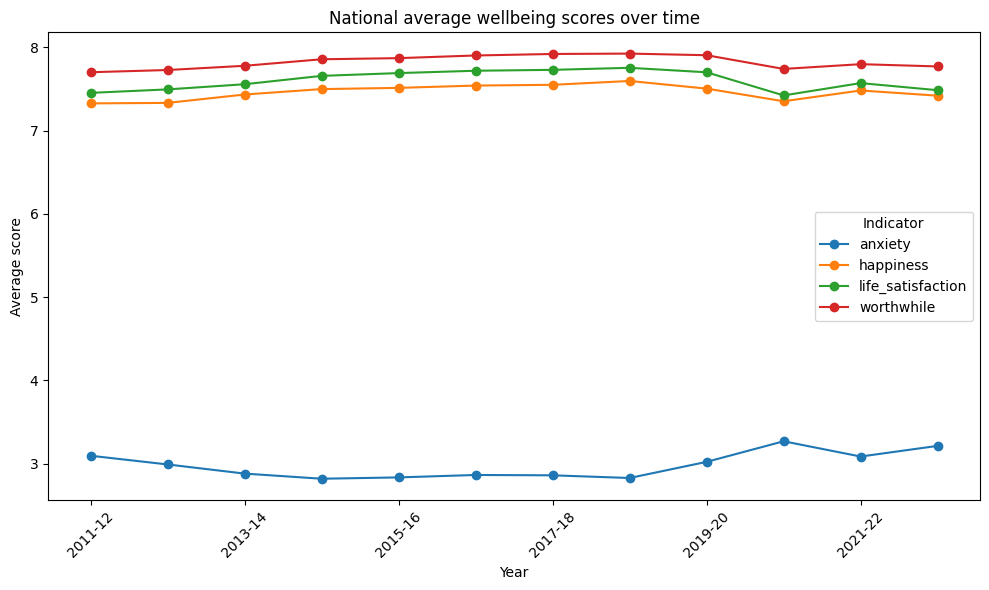

In [ ]:
import matplotlib.pyplot as plt

# Plot national trends over time in a line chart
national_trends.plot(figsize=(10, 6), marker="o")

plt.title("National average wellbeing scores over time")
plt.xlabel("Year")
plt.ylabel("Average score")
plt.xticks(rotation=45)
plt.legend(title="Indicator")
plt.tight_layout()
plt.show()

The national trend chart shows that average wellbeing scores were broadly stable over the period, but with some noticeable changes over time. Happiness, life satisfaction and worthwhile all increased gradually between 2011–12 and the late 2010s, suggesting a modest improvement in overall wellbeing at the national level during this period.

In contrast, average anxiety scores fell slightly between 2011–12 and around 2018–19, which shows an improvement, as lower anxiety scores reflect better wellbeing. However, this pattern changed after 2019–20. Anxiety rose sharply in 2020–21, while happiness, life satisfaction and worthwhile all fell at the same time. This suggests a clear fall in national wellbeing during that period.

The chart also shows some recovery after 2020–21, with anxiety falling back and the other three indicators rising again. However, by 2022–23 the measures had not fully returned to their pre-2020 trend.

Overall, the national picture is one of gradual improvement over the earlier part of the period, followed by more disruption and not a full recovery in the later years. These trends will be explored deeper at local levels.

**7. Benchmark local authorities**

Question:
Which local authorities are performing above or below the national average in the latest year?

To benchmark local authorities, I focused on the most recent year in the dataset, 2022–23. This gives the clearest picture of current performance and allows each authority to be compared with the national average for the same year and indicator.

For each wellbeing measure, I calculated the gap between the local authority score and the national average. Because anxiety works in the opposite direction to the other three indicators, I adjusted the benchmark gap so that positive values always represent better-than-average outcomes. This makes the charts easier to read and keeps the interpretation consistent across all four indicators.

In [ ]:
# Creating a latest year benchmarking table

# Filter to the latest year
latest_year = "2022-23"
latest = wellbeing[wellbeing["year"] == latest_year].copy()

# Calculate difference from national average
latest["difference_from_national"] = latest["score"] - latest["national_average"]

# Create a direction-adjusted benchmarking measure, so it's easier to compare anxiety
# So positive values always mean "better than national average"
latest["benchmark_gap"] = latest["difference_from_national"]
#  For rows where the indicator is anxiety, replace benchmark_gap with the negative version of difference_from_national
latest.loc[latest["indicator"] == "anxiety", "benchmark_gap"] = (
    latest.loc[latest["indicator"] == "anxiety", "difference_from_national"] * -1
)

display(latest.head())

,area_code,area_name,year,indicator,score,national_average,difference_from_national,benchmark_gap
4114,E06000001,Hartlepool,2022-23,anxiety,3.48,3.21303,0.26697,-0.26697
4115,E06000002,Middlesbrough,2022-23,anxiety,3.07,3.21303,-0.14303,0.14303
4116,E06000003,Redcar and Cleveland,2022-23,anxiety,3.25,3.21303,0.03697,-0.03697
4117,E06000004,Stockton-on-Tees,2022-23,anxiety,3.23,3.21303,0.01697,-0.01697
4118,E06000005,Darlington,2022-23,anxiety,3.38,3.21303,0.16697,-0.16697


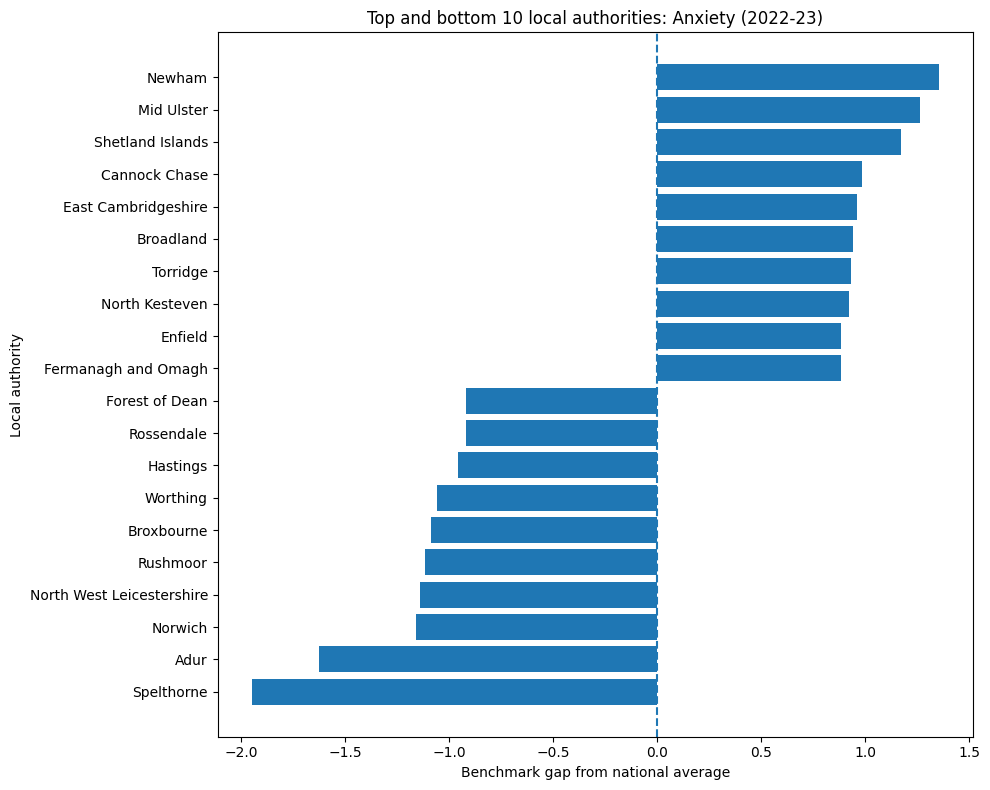

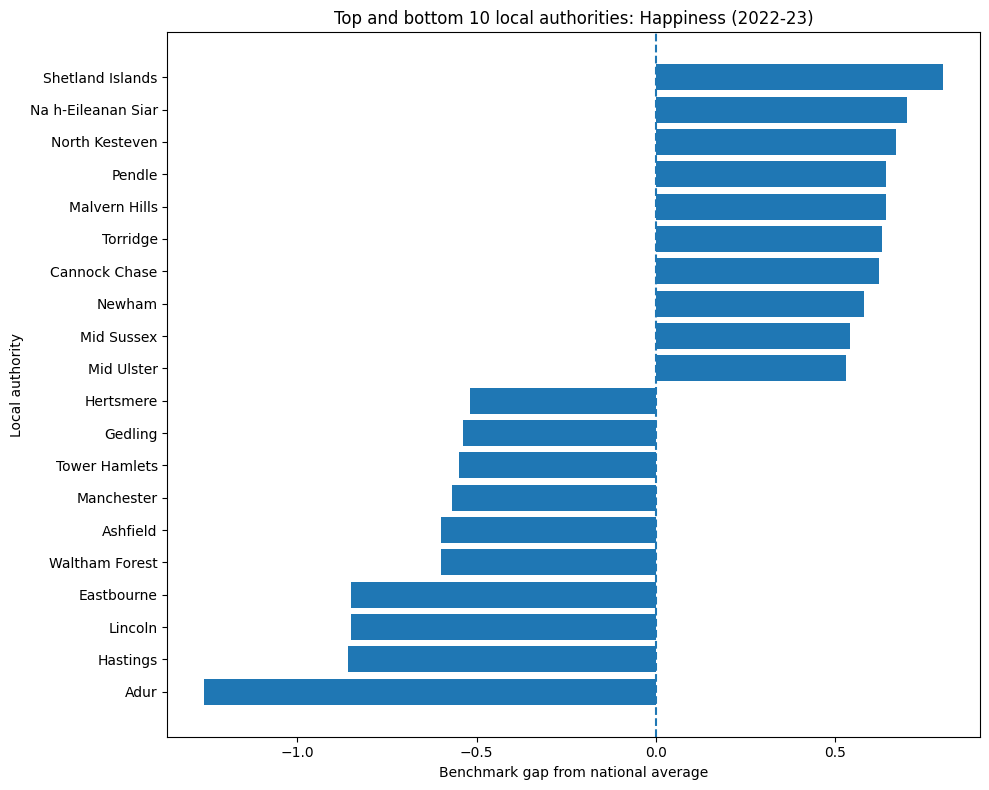

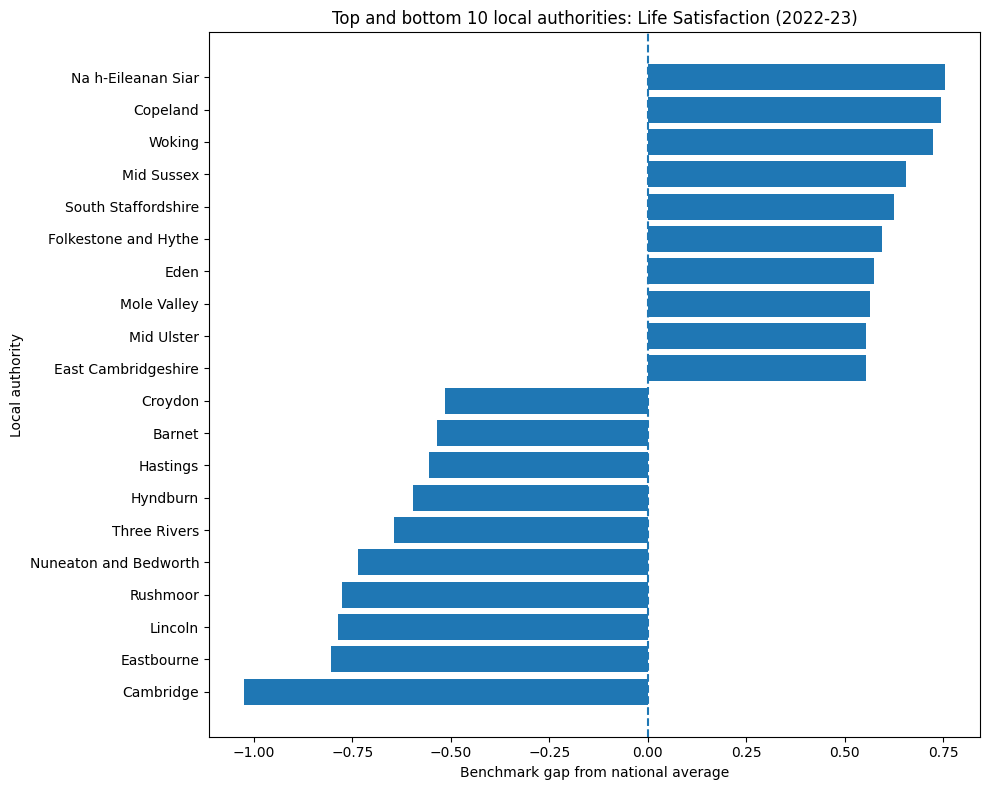

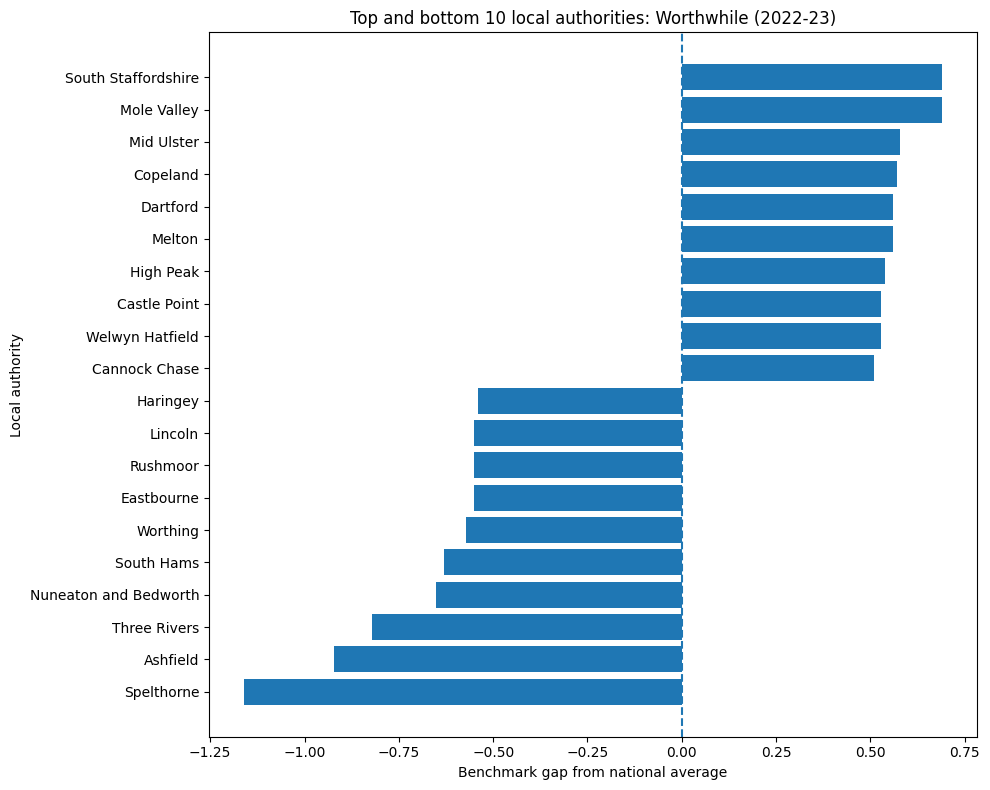

In [ ]:
# Chart top 10 and bottom 10 local authorities for each indicator in the latest year

# Create a smaller dataframe called plot_df for the chart, which ensures it only keeps rows that match the current indicator in the loop, and excludes authorities with null scores.
for indicator in latest["indicator"].unique():
    plot_df = latest[
        (latest["indicator"] == indicator) &
        (latest["score"].notna())
    ].copy()

    # Sort the top and bottom benchmark gaps
    top_10 = plot_df.sort_values("benchmark_gap", ascending=False).head(10)
    bottom_10 = plot_df.sort_values("benchmark_gap", ascending=True).head(10)

    # Combine the top and bottom 10 table, and sort them from highest to lowest for clearer visualisation
    chart_df = pd.concat([bottom_10, top_10]).copy()
    chart_df = chart_df.sort_values("benchmark_gap")

    # Start a new figure, draw a horixontal bar chart, add a dashed reference line at zero, make the titles more readable, label x and y axis, adjust spacing, and show the charts.
    plt.figure(figsize=(10, 8))
    plt.barh(chart_df["area_name"], chart_df["benchmark_gap"])
    plt.axvline(0, linestyle="--")
    plt.title(f"Top and bottom 10 local authorities: {indicator.replace('_', ' ').title()} ({latest_year})")
    plt.xlabel("Benchmark gap from national average")
    plt.ylabel("Local authority")
    plt.tight_layout()
    plt.show()

**Benchmarking summary**

These charts show that local authority wellbeing in 2022–23 varies clearly around the national average. Across all four indicators, some authorities perform well above the benchmark, while others fall noticeably below it, showing that wellbeing outcomes differ meaningfully between places.

The charts are designed to make those differences easy to interpret. For happiness, life satisfaction and worthwhile, higher scores indicate better outcomes. For anxiety, the benchmark gap has been adjusted so that positive values also represent better performance, allowing all four charts to be read in the same way.

Showing only the top and bottom 10 authorities keeps the charts clear and avoids overcrowding, while still highlighting the scale of variation across the country. This provides a useful benchmark view of current performance and helps identify where further comparison or investigation may be most useful.

**8. Compare selected authorities and indicators**

Question:
How does Brighton and Hove compare with a stronger and weaker comparator across the four indicators?

To move beyond overall benchmarking, I compared a small set of selected local authorities across the four wellbeing indicators. This allows the analysis to focus more closely on how different places perform, rather than only showing where they rank nationally.

Brighton and Hove was selected as the main authority of interest. To provide context, I also selected Folkestone and Hythe as a stronger comparator, and Hastings as a weaker comparator based on overall benchmarking performance in 2022–23. The comparators were also chosen due to their location in South East England, hence providing useful insight for this specific region.

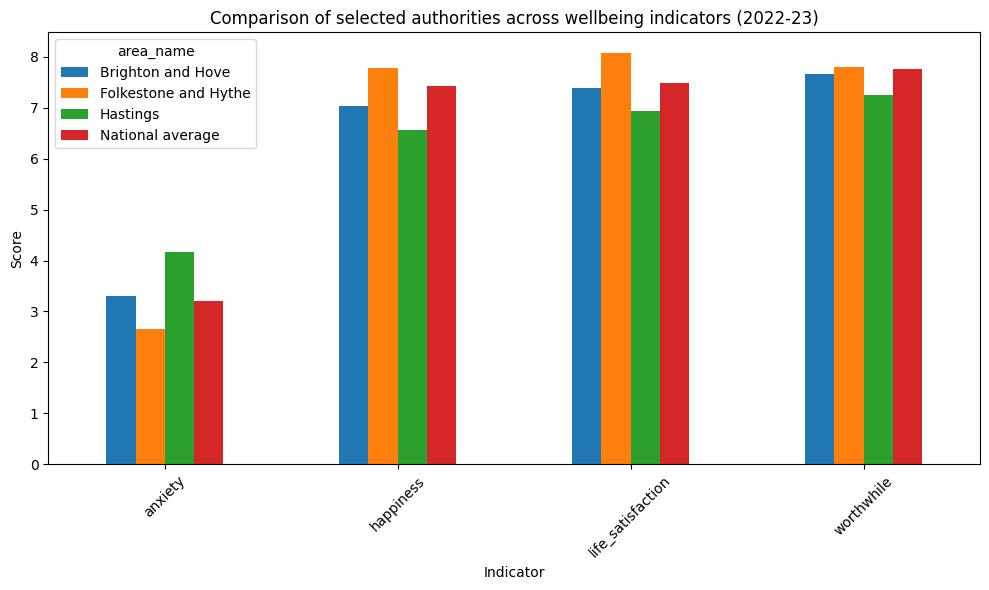

In [ ]:
# Select the authorities to compare
selected_authorities = [
    "Brighton and Hove",
    "Folkestone and Hythe",
    "Hastings"
]

# Filter the latest-year data for those authorities
selected_latest = latest[latest["area_name"].isin(selected_authorities)].copy()

# Create national average rows for the same year
national_latest = national_averages[national_averages["year"] == latest_year].copy()
national_latest["area_name"] = "National average"
national_latest["score"] = national_latest["national_average"]

# Keep only the columns needed for comparison
national_latest = national_latest[["area_name", "indicator", "score"]]
selected_latest = selected_latest[["area_name", "indicator", "score"]]

# Combine selected authorities with the national average
comparison_df = pd.concat([selected_latest, national_latest], ignore_index=True)

# Reshape for plotting
comparison_pivot = comparison_df.pivot(
    index="indicator",
    columns="area_name",
    values="score"
)

# Create grouped bar chart
comparison_pivot.plot(kind="bar", figsize=(10, 6))

plt.title(f"Comparison of selected authorities across wellbeing indicators ({latest_year})")
plt.xlabel("Indicator")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Comparison summary**

This comparison shows that Brighton and Hove sits between the stronger comparator, Folkestone and Hythe, and the weaker comparator, Hastings, across most of the wellbeing indicators in 2022–23. Folkestone and Hythe performs most strongly overall, with higher scores than both Brighton and Hove and the national average on happiness, life satisfaction and worthwhile, as well as lower anxiety. Hastings shows the weakest profile, with higher anxiety and lower scores on the three positive wellbeing measures.

Brighton and Hove appears close to the national average overall, but its pattern is mixed. It performs below the national average on happiness and life satisfaction, is slightly below the national average on worthwhile, and has slightly higher anxiety than the national benchmark. This suggests that Brighton and Hove’s wellbeing profile is somewhat weaker than the national picture, although not as weak as Hastings.

Looking across all four indicators together is useful because it shows that local wellbeing is not evenly distributed across these authorities.

**9. Interactive comparison over time**

Question:
How has happiness changed over time in Brighton and Hove compared with the national average and selected comparator authorities?

To add a more detailed time-based view, I created an interactive Plotly line chart showing happiness over time for Brighton and Hove, Folkestone and Hythe, Hastings, and the national average. This makes it possible to look beyond the latest year and see whether the gap between these areas has remained stable or changed over time.

I used happiness for this interactive example because of the particularly large range in scores in the previous chart, making it a particularly interesting indicator to investigate further.

In [ ]:
import plotly.express as px

# Choose one indicator to track over time
indicator_choice = "happiness"

# Select the authorities of interest, and create a list
selected_authorities = [
    "Brighton and Hove",
    "Folkestone and Hythe",
    "Hastings"
]

# Create a smaller dataframe by filtering the main wellbeing table, keeping only rows with the happiness indicator or one of the selected authorities, and keeping only three columns.
selected_time = wellbeing[
    (wellbeing["indicator"] == indicator_choice) &
    (wellbeing["area_name"].isin(selected_authorities))
][["area_name", "year", "score"]].copy()

# Filter the national_averages table created earlier to only show rows with the 'happiness' indicator, and keep the columns 'year' and 'national_average'
national_time = national_averages[
    national_averages["indicator"] == indicator_choice
][["year", "national_average"]].copy()

# Make the national average dataset have the same columns as the selected authorities dataframe, so it can be plotted in the same way
national_time["area_name"] = "National average" # This just makes a new column called 'area name' to match the column for the selected authorities dataframe, and fills every row with 'National average'
national_time["score"] = national_time["national_average"] # Takes the national average and puts it into the score column
national_time = national_time[["area_name", "year", "score"]]

# Combine the national average dataset with the selected authority dataset
plotly_df = pd.concat([selected_time, national_time], ignore_index=True)

# Force year to be read as plain text
plotly_df["year"] = plotly_df["year"].astype(str)

# Set the year order
year_order = [
    "2011-12", "2012-13", "2013-14", "2014-15",
    "2015-16", "2016-17", "2017-18", "2018-19",
    "2019-20", "2020-21", "2021-22", "2022-23"
]

# Create chart
fig = px.line(
    plotly_df,
    x="year",
    y="score",
    color="area_name",
    markers=True,
    category_orders={"year": year_order},
    title="Happiness over time: selected authorities vs national average"
)

# Final fix to x-axis - force x-axis to be categorical (tells Plotly to treat the x-axis as categories, and not to interpret them as dates). Then update capitalisation on the axis labels.
fig.update_xaxes(type="category")

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Score"
)

fig.show()

This chart suggests that Brighton and Hove remains fairly close to the national average throughout, although it is generally slightly below it in most years. Folkestone and Hythe tends to perform more strongly overall, with happiness scores often above the national benchmark ( except for the drop in 2017-18, with a sharp recovery in 2018-19). Hastings shows the most volatility, with sharper rises and falls over time, including a particularly marked drop in 2022–23.

Overall, the chart suggests that Brighton and Hove has a relatively stable but slightly below-average happiness profile, positioned between a stronger and a weaker comparator.

A small technical adjustment was also needed - the year values in the dataset are financial-year labels such as 2011-12, instead of standard calendar dates. Plotly initially tried to interpret these as date-time values, so the year field was treated as a categorical text variable and its order was set manually to display the x-axis correctly.


---



# Stage 3: Findings and Discussion

**10. Key findings for decision makers**

This analysis shows that wellbeing varies clearly between local authorities, both in the latest year and over time. National averages provide useful context, but they do not tell the full story on their own. Looking across all four indicators gives a more balanced picture of local wellbeing and makes it easier to identify where outcomes appear stronger or weaker.

**National-level Insights:**

* **The four indicators should be looked at together.** The scores differ between indicators, so all must be looked at for a full picture.

* **There is clear variation between authorities.** Local authorities must be careful to assess their wellbeing individually due to the high variation between areas.

* **National trends changed sharply around 2020–21.** Happiness, life satisfaction and worthwhile all declined at that point, while anxiety rose. This was the most concerning shift in the analysis, and although there is some recovery afterwards, the indicators had not fully returned to their earlier pattern by 2022–23. This should be emphasised as a worrying national trend and investigated further, although some areas were affected more than others.

**Local-level Insights for Brighton and Hove:**

* **Brighton and Hove performs close to the national average, but with a slightly weaker overall profile.** In the selected-authority comparison, Brighton and Hove does not stand out as either a particularly high- or low-performing area, but it sits slightly below the national average on happiness, life satisfaction and worthwhile, and slightly above the national average on anxiety. Taken together, this suggests a mild but consistent wellbeing gap rather than a single isolated weakness.

* **Brighton and Hove sits between a stronger and a weaker comparator.** Folkestone and Hythe shows a stronger profile across all four indicators, while Hastings performs more weakly overall. This places Brighton and Hove in the middle of the three authorities, which is helpful for understanding its position in relative rather than absolute terms.

(On a separate note, Hastings' continual underperformance and concerningly sharp decline in the most recent years requires immediate attention from both local authorities and at the national level, due to the severity of low wellbeing scores.)

* **Tracking change over time is important for local interpretation.** The interactive happiness chart suggests that Brighton and Hove remains fairly close to the national average over time, but generally slightly below it in most years. This points to a relatively stable pattern rather than a sudden recent decline, which may a long-term local wellbeing challenge, instead of a short-term fluctuation.

Overall, the findings suggest that local authorities should assess wellbeing by looking across all four measures, comparing local results with both the national average and relevant peer areas, and monitoring whether recent changes reflect a local issue or a wider national pattern. From a policy perspective, this is important because local wellbeing trends do not exist in isolation: some shifts may reflect broader national pressures, while others may point to more specific local challenges. The most useful next step is therefore not simply to note where an authority ranks, but to use the evidence to guide more targeted local enquiry and practical decision-making.

**11. Limitations**

This analysis is intended to support benchmarking and monitoring, not to identify causes. The ONS wellbeing indicators show where local outcomes are stronger or weaker and how they change over time, but they do not reveal why those differences exist.

In practice, local wellbeing may be shaped by a wide range of factors, including inequality, housing pressures, local services, employment conditions, cost of living, transport, social isolation or the specific needs of different communities. These factors are not directly measured in this notebook, so the findings should be used carefully and in context.

This matters for decision makers because a weaker score should not automatically be interpreted as evidence of one specific local problem. Instead, it should be treated as a prompt for more focused local investigation.

**12. Questions for further local enquiry**

The results for Brighton and Hove suggest a slightly weaker overall wellbeing profile than the national average, but not a single extreme outlier that points to one obvious explanation. This makes it especially important to move from benchmarking to enquiry.

Some useful follow-up questions for a local authority decision maker would be:

* Is this pattern shared across the whole authority, or are some communities experiencing much lower wellbeing than others?

* Has Brighton and Hove remained slightly below the national average over time, or has the gap widened in recent years?

* What local pressures might help explain slightly weaker scores on happiness, life satisfaction and worthwhile, alongside slightly higher anxiety?

* What can be learned from stronger comparator authorities such as Folkestone and Hythe?

* Which local services, policy areas or community groups would be most useful to explore next in order to understand these patterns better?

This kind of follow-up questioning is important because the value of the analysis lies not only in identifying a gap, but in helping decision makers understand where further evidence gathering should be focused.

If this prototype were developed further in a live client setting, the next stage would be to combine this benchmarking analysis with deeper local investigation. That could include qualitative research with residents or stakeholders, more detailed subgroup analysis, or comparison with other locally held evidence. This would help move from identifying where wellbeing appears weaker to understanding why and what kind of response may be most useful.

**13. AI Usage Log:**

AI tools were used during this project to support the development of the notebook. This included help with structuring the analysis, improving markdown commentary, debugging Python code, generating and explaining more complex code, and troubleshooting chart issues. AI was also used to suggest ways of presenting the data clearly for a non-technical audience. All analysis decisions and code were reviewed and understood before being included in the final notebook. For full transparency, a more specific list is included below:

* Consistently used for debugging throughout steps.
* Stage 1, Step 3: Used to debug and help generate reshaping and renaming the merged dataset.
* Stage 2, Step 6: Used to debug and improve code to generate line chart. Used to clarify and communicate the insights I noticed from the line chart.
* Stage 2, Step 7: Used to debug benchmark table code, and to help generate code for adding a direction-adjusted benchmarking measure.
* Stage 2, Step 8: Used to help generate code to create a new dataset including only the information needed for the comparison bar chart, in the correct format.
* Stage 2, Step 9: Used to help generate code to produce Plotly interactive graph, and to add extra needed code to give the correct diplay for the x-axis, as explained in the markdown.

